In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")


california_url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
california_df = pd.read_csv(california_url)

print("Dataset Dimensions (rows, cols):", california_df.shape)
california_df.head()

Dataset Dimensions (rows, cols): (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
california_df.info()
print("\nMissing values per column:\n", california_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Missing values per column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_v

In [3]:

california_df["total_bedrooms"] = california_df["total_bedrooms"].fillna(
    california_df["total_bedrooms"].median()
)


california_df = pd.get_dummies(california_df, columns=["ocean_proximity"], drop_first=True)

print("Missing values after cleaning:\n", california_df.isnull().sum().sum())
california_df.head()

Missing values after cleaning:
 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [4]:
features = [col for col in california_df.columns if col != "median_house_value"]
X = california_df[features]
y = california_df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nFirst 3 rows of target data:")
print(y_train.head(3))

Training set size: (16512, 12)
Test set size: (4128, 12)

First 3 rows of target data:
14196    103000.0
8267     382100.0
17445    172600.0
Name: median_house_value, dtype: float64


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardized training features mean (approx 0):", round(X_train_scaled.mean(), 4))
print("Standardized training features std dev (approx 1):", round(X_train_scaled.std(), 4))

Standardized training features mean (approx 0): 0.0
Standardized training features std dev (approx 1): 1.0


In [6]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)   # unscaled features work fine for plain linear regression
lr_predictions = lr_model.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance Metrics")
print("-------------------------------------")
print(f"Mean Absolute Error (MAE)      : {lr_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {lr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {lr_rmse:.4f}")
print(f"R² Score                       : {lr_r2:.4f}")

Linear Regression Performance Metrics
-------------------------------------
Mean Absolute Error (MAE)      : 50670.7382
Mean Squared Error (MSE)       : 4908476721.1566
Root Mean Squared Error (RMSE) : 70060.5218
R² Score                       : 0.6254


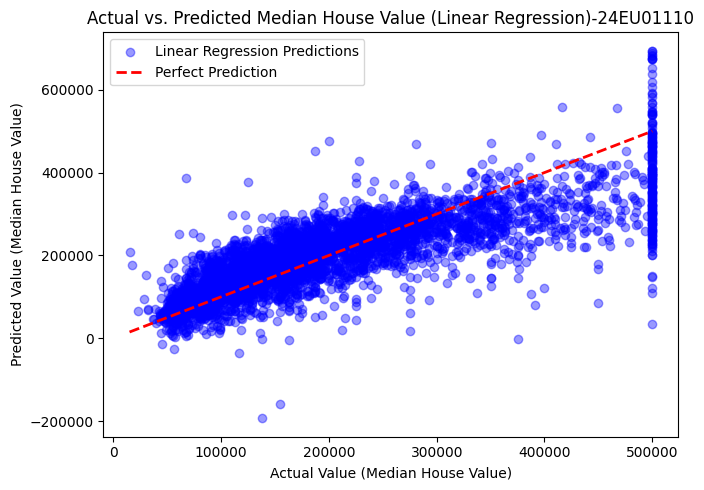

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, lr_predictions, color='blue', alpha=0.4, label='Linear Regression Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Actual vs. Predicted Median House Value (Linear Regression)-24EU01110")
plt.xlabel("Actual Value (Median House Value)")
plt.ylabel("Predicted Value (Median House Value)")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

svr_model = SVR(kernel='rbf', C=10, gamma='scale')
svr_model.fit(X_train_scaled, y_train_scaled)

svr_predictions_scaled = svr_model.predict(X_test_scaled)
svr_predictions = y_scaler.inverse_transform(svr_predictions_scaled.reshape(-1, 1)).ravel()

In [10]:
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

print("Support Vector Regression Performance Metrics")
print("---------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {svr_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {svr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {svr_rmse:.4f}")
print(f"R² Score                       : {svr_r2:.4f}")

Support Vector Regression Performance Metrics
---------------------------------------------
Mean Absolute Error (MAE)      : 36146.5040
Mean Squared Error (MSE)       : 3021648007.4425
Root Mean Squared Error (RMSE) : 54969.5189
R² Score                       : 0.7694


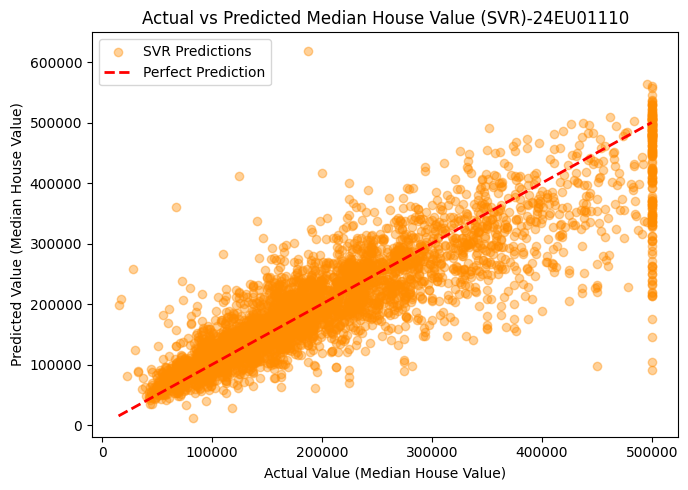

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, svr_predictions, color='darkorange', alpha=0.4, label='SVR Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Actual vs Predicted Median House Value (SVR)-24EU01110")
plt.xlabel("Actual Value (Median House Value)")
plt.ylabel("Predicted Value (Median House Value)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
from sklearn.tree import DecisionTreeRegressor


dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

In [13]:
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Regression Performance Metrics")
print("--------------------------------------------")
print(f"Mean Absolute Error (MAE)      : {dt_mae:.4f}")
print(f"Mean Squared Error (MSE)       : {dt_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {dt_rmse:.4f}")
print(f"R² Score                       : {dt_r2:.4f}")

Decision Tree Regression Performance Metrics
--------------------------------------------
Mean Absolute Error (MAE)      : 42866.1490
Mean Squared Error (MSE)       : 3946099051.6432
Root Mean Squared Error (RMSE) : 62817.9835
R² Score                       : 0.6989


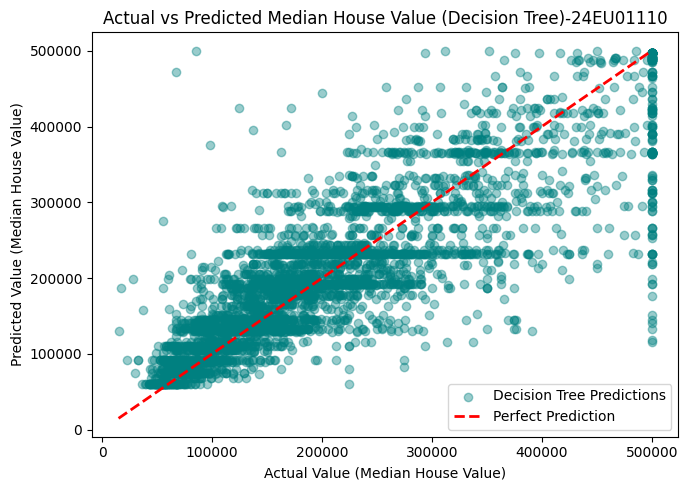

In [14]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, dt_predictions, color='teal', alpha=0.4, label='Decision Tree Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Actual vs Predicted Median House Value (Decision Tree)-24EU01110")
plt.xlabel("Actual Value (Median House Value)")
plt.ylabel("Predicted Value (Median House Value)")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
performance = pd.DataFrame({
    "Model": ["Linear Regression", "Support Vector Regression", "Decision Tree Regression"],
    "MAE": [lr_mae, svr_mae, dt_mae],
    "MSE": [lr_mse, svr_mse, dt_mse],
    "RMSE": [lr_rmse, svr_rmse, dt_rmse],
    "R² Score": [lr_r2, svr_r2, dt_r2]
})
print("Regression Model Performance Comparison")
print(performance.to_string(index=False))

Regression Model Performance Comparison
                    Model          MAE          MSE         RMSE  R² Score
        Linear Regression 50670.738241 4.908477e+09 70060.521845  0.625424
Support Vector Regression 36146.504002 3.021648e+09 54969.518894  0.769412
 Decision Tree Regression 42866.148986 3.946099e+09 62817.983505  0.698865


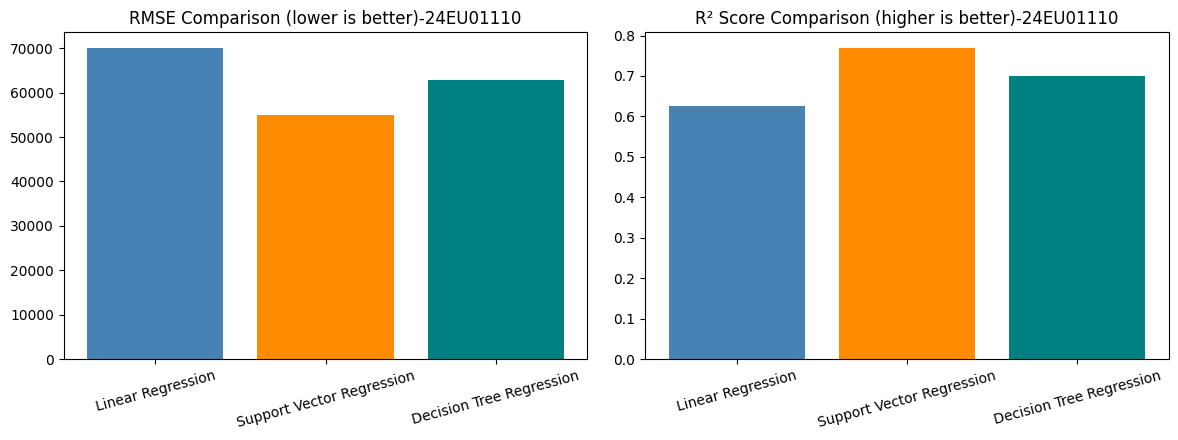

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(performance["Model"], performance["RMSE"], color=["steelblue", "darkorange", "teal"])
axes[0].set_title("RMSE Comparison (lower is better)-24EU01110")
axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(performance["Model"], performance["R² Score"], color=["steelblue", "darkorange", "teal"])
axes[1].set_title("R² Score Comparison (higher is better)-24EU01110")
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()